# PSO
---
## Requisitos
### Valores fixos
- 3 problemas: Esfera, Rastrigin e Rosenbrock
- Dimensão = 30

### Valores mutáveis
- Fator inércia: constante ou decaimento linear
- Cooperação: global ou local
- Quantidade de indivíduos = 30 (mas pode mudar)
- Iterações = 20 (mas pode mudar)
- c1 e c2 = 2.05 

## Funções

In [1]:
import math
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
def sphere(x):
    """
    Sphere Function
    Mínimo global: f(0, ..., 0) = 0
    """
    return sum(xi**2 for xi in x)


def rastrigin(x):
    """
    Rastrigin Function
    Mínimo global: f(0, ..., 0) = 0
    """
    n = len(x)
    return 10 * n + sum(xi**2 - 10 * np.cos(2 * np.pi * xi) for xi in x)

def rosenbrock(x):
    """
    Rosenbrock Function
    Mínimo global: f(1, ..., 1) = 0
    """
    return sum(100 * (x[i+1] - x[i]**2)**2 + (x[i] - 1)**2 for i in range(len(x)-1))

## Parâmetros

In [3]:
DIMENSIONS = 30              # Numero de dimensões do espaço de busca
GLOBAL_BEST = 0             # Melhor valor global conhecido para a função objetivo
INERTIA_W = 0.8              # Pesos de inércia 
W_MAX = 0.9                     # deacimento linear (valores entre 0.9 e 0.4)
W_MIN = 0.4

INERTIA = 'linear'          # Tipo de peso de inércia (constante ou linear)
TOPOLOGY_MODE = 'global'     # Modo de topologia (global ou local)
POPULATION = 100             # úmero de partículas no enxame7
C1 = 2.05            # Fator do coeficiente pessoal
C2 = 2.05              # Fator do coeficiente social
MAX_ITER = 500             # Número máximo de iterações

CONVERGENCE = 0.001         # Valor de convergência
RANDOM_SEED = 42           # Semente aleatória para reprodutibilidade
EXECUTIONS = 30             # úmero de execuções para cada função

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## PSO

In [4]:
class Particle():
    def __init__(self, pos, z, velocity):
        self.pos = pos
        self.pos_z = z
        self.velocity = velocity
        self.best_pos = self.pos.copy()
        self.best_pos_z = z

In [5]:
class Swarm():
    def __init__(self, pop, v_max, actual_function, b_lo, b_hi):
        self.particles = []             
        self.best_pos = None            
        self.best_pos_z = math.inf      

        for _ in range(pop):
            pos = np.random.uniform(b_lo, b_hi, DIMENSIONS)
            
            # Passa o array inteiro para a função de custo
            z = actual_function(pos) 
            
            # Gera um array de velocidade para todas as 30 dimensões
            velocity = np.random.rand(DIMENSIONS) * v_max

            particle = Particle(pos, z, velocity)
            self.particles.append(particle)
            
            if self.best_pos is not None and particle.pos_z < self.best_pos_z:
                self.best_pos = particle.pos.copy()
                self.best_pos_z = particle.pos_z
            elif self.best_pos is None:
                self.best_pos = particle.pos.copy()
                self.best_pos_z = particle.pos_z

In [6]:
def particle_swarm_optimization(inertia='linear', topology_mode='global'):
    resultados_finais = {}

    for actual_function in [sphere, rastrigin, rosenbrock]:

        if actual_function.__name__ == 'rastrigin':
            b_lo, b_hi = -5.12, 5.12
        elif actual_function.__name__ == 'rosenbrock':
            b_lo, b_hi = -30.0, 30.0
        else: # sphere
            b_lo, b_hi = -100.0, 100.0
            
        v_max_dinamico = 0.2 * (b_hi - b_lo)

        curvas_desta_funcao = []

        for execution in range(EXECUTIONS):
            convergence_curve = []

            #print(f"Executando {actual_function.__name__} - Rodada {execution + 1}")
            swarm = Swarm(POPULATION, v_max_dinamico, actual_function, b_lo, b_hi)

            seed_atual = RANDOM_SEED + execution
            random.seed(seed_atual)
            np.random.seed(seed_atual)
            
            curr_iter = 0
            while curr_iter < MAX_ITER:

                if inertia == 'constant':
                    inertia_weight = 0.729
                elif inertia == 'linear':
                    W_MAX, W_MIN = 0.9, 0.4
                    inertia_weight = W_MAX - curr_iter * ((W_MAX - W_MIN) / MAX_ITER)

                for p_idx, particle in enumerate(swarm.particles):

                    if topology_mode == 'global':
                        social_best_pos = swarm.best_pos
                    elif topology_mode == 'local':
                        left_neighbor = swarm.particles[(p_idx - 1) % POPULATION]
                        right_neighbor = swarm.particles[(p_idx + 1) % POPULATION]
                        
                        z_left = actual_function(left_neighbor.best_pos)
                        z_self = actual_function(particle.best_pos)
                        z_right = actual_function(right_neighbor.best_pos)
                        
                        best_local_z = min(z_left, z_self, z_right)

                        if best_local_z == z_left:
                            social_best_pos = left_neighbor.best_pos
                        elif best_local_z == z_right:
                            social_best_pos = right_neighbor.best_pos
                        else:
                            social_best_pos = particle.best_pos

                    for i in range(DIMENSIONS):
                        r1 = np.random.uniform(0, 1)
                        r2 = np.random.uniform(0, 1)
                        
                        personal_coefficient = C1 * r1 * (particle.best_pos[i] - particle.pos[i])
                        social_coefficient = C2 * r2 * (social_best_pos[i] - particle.pos[i])
                        
                        new_velocity = inertia_weight * particle.velocity[i] + personal_coefficient + social_coefficient

                        if new_velocity > v_max_dinamico:
                            particle.velocity[i] = v_max_dinamico
                        elif new_velocity < -v_max_dinamico:
                            particle.velocity[i] = -v_max_dinamico
                        else:
                            particle.velocity[i] = new_velocity

                    # Atualizar posição da partícula usando cálculo vetorial do Numpy
                    particle.pos += particle.velocity
                    
                    # Checar limites das 30 dimensões
                    for i in range(DIMENSIONS):
                        if particle.pos[i] > b_hi:
                            particle.pos[i] = b_hi
                            particle.velocity[i] = 0  # Zera a velocidade nesse eixo (bateu na parede)
                        elif particle.pos[i] < b_lo:
                            particle.pos[i] = b_lo
                            particle.velocity[i] = 0
                    
                    # Atualiza o custo da partícula
                    particle.pos_z = actual_function(particle.pos)

                    # Atualiza os melhores conhecidos
                    if particle.pos_z < actual_function(particle.best_pos):
                        particle.best_pos = particle.pos.copy()

                        if particle.pos_z < swarm.best_pos_z:
                            swarm.best_pos = particle.pos.copy()
                            swarm.best_pos_z = particle.pos_z

                # Salva o melhor valor do enxame na iteração atual
                convergence_curve.append(swarm.best_pos_z)

                if abs(swarm.best_pos_z - GLOBAL_BEST) < CONVERGENCE:
                    print(f"Convergência atingida na iteração {curr_iter}.")
                    resto_iters = MAX_ITER - curr_iter - 1
                    convergence_curve.extend([swarm.best_pos_z] * resto_iters)
                    break
                    
                curr_iter += 1

            curvas_desta_funcao.append(convergence_curve)
        
        media_curvas = np.mean(curvas_desta_funcao, axis=0)
        resultados_finais[actual_function.__name__] = media_curvas

        print(f"Função: {actual_function.__name__} - Melhor valor encontrado: {swarm.best_pos_z:.6f}")


    # Visualização das curvas de convergência médias para cada função
    plt.figure(figsize=(10, 6))
    
    for nome_funcao, media_curva in resultados_finais.items():
        curva_segura = [max(val, 1e-10) for val in media_curva]
        plt.plot(curva_segura, label=nome_funcao.capitalize(), linewidth=2)

    plt.title(f"Curva de Convergência Média ({EXECUTIONS} Execuções - {DIMENSIONS}D)")
    plt.xlabel("Iterações")
    plt.ylabel("Melhor Custo (Z) - Escala Log")
    plt.yscale("log") # Importante manter logarítmico para ver as quedas acentuadas
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Função: sphere - Melhor valor encontrado: 0.590423
Função: rastrigin - Melhor valor encontrado: 46.342217
Função: rosenbrock - Melhor valor encontrado: 266.433756


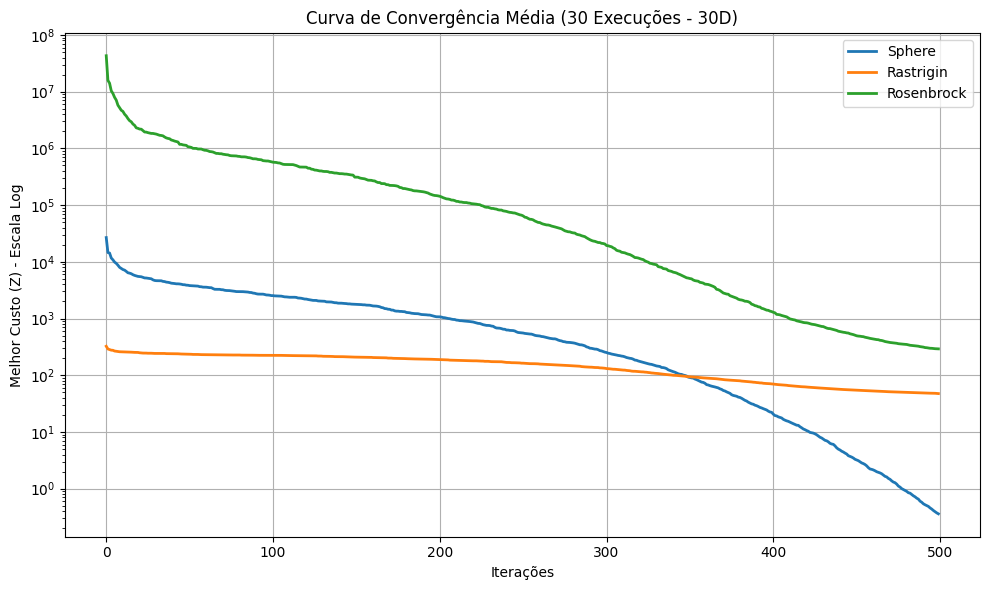

In [7]:
particle_swarm_optimization(INERTIA, TOPOLOGY_MODE)